# Install Libraries

In [1]:
# !pip install beautifulsoup4
# !pip install pandas
# !pip install matplotlib
# !pip install requests
# !pip install numpy

# Import Libraries

In [2]:
from bs4 import BeautifulSoup as bs
import pandas as pd
import matplotlib.pyplot as plt
import requests
import numpy as np

# Create Offer Class

method of this class prepares row which will be inserted into pandas data frame

In [3]:
class Offer:
    def __init__(self, name, company, location, min_salary, max_salary):
        self.offer_name = name
        self.company_name = company
        self.location = location
        self.min_salary = min_salary
        self.max_salary = max_salary

    def print_object(self):
        print(self.offer_name, self.company_name, self.location, self.min_salary, self.max_salary)

    def prep_for_extraction(self):
        return {'name':self.offer_name, 'company':self.company_name, 'location':self.location, 'min_wage':self.min_salary, 'max_wage':self.max_salary}

# Pick Offer Keyword

In [4]:
tech = 'c++'

List of offers will be needed to create data frame

In [5]:
offers = list()

# While loop used to loop through all pages

Then key offer data is extracted and validated to construct Offer object and appendend it to offers list

In [6]:
page = 1
while True:
    URL = 'https://bulldogjob.pl/companies/jobs/s/skills,%s/with_salary,true?page=%s' % (tech, page)
    handle = requests.get(URL)
    soup = bs(handle.content, 'html.parser')
    boxes = soup.find_all('a', class_='search-list-item')

    if boxes is None or page == 2:
        break
    

    for box in boxes:
        offer_name = box.select('h3')[0].text.strip()
        company_name = box.select('div.company')[0].text.strip()
        location = box.select('div.location')[0].text.strip()
        salary = box.find('div', class_='salary').get_text(strip=True).split('-')
        min_salary = None
        max_salary = None
        
        offer = None
        
        if len(salary) < 2:
            if salary[0].isnumeric():
                max_salary = int(salary[0])
            else:
                salary = None
        else:
            min_salary = int(salary[0].strip().replace(' ', ''))
            max_salary = int(salary[1].strip().replace(' ', '').replace('PLN', ''))
            
            
        locations = location.split(',')
        for city in locations:
            if 'więcej' in city:
                city = (city.split(' '+'i'+' ')[0])

            offer = Offer(offer_name, company_name, city.strip(), min_salary, max_salary) 
            offers.append(offer.prep_for_extraction())
    
    page += 1

In [7]:
# Creat

In [8]:
df = pd.DataFrame(offers)

In [9]:
temp = df.copy()
temp['avg_wage'] = (temp['min_wage'] + temp['max_wage'])/2

In [10]:
temp[(temp['location']=='Warszawa')]

,name,company,location,min_wage,max_wage,avg_wage
12,Software Developer (C++),ONWELO SA,Warszawa,12000.0,22000.0,17000.0
15,Programista Embedded C/C++,Enigma SOI,Warszawa,NaN,NaN,NaN


# Pie Chart  the percentage distribution of offers by city

list of locations for further use in plots

In [11]:
locations = list(temp['location'].drop_duplicates())

list of jobs quantity in each location

In [12]:
counts = []
for city in locations:
    counts.append(len(temp[(temp['location']==city)]))

# Visualise Plot

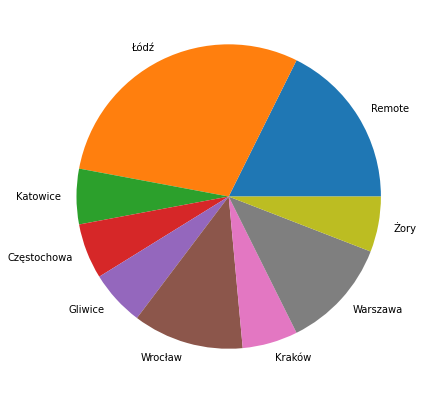

In [13]:
fig = plt.figure(figsize =(10, 7))
plt.pie(counts, labels = locations)
plt.show()

# Bar Chart AVG Salary Depending On City

Filter dataFrame, gather and validate salary data depending on localisation and append to list of average salaries 

In [14]:
avg_salary = []
for city in locations:
    by_location = (temp[(temp['location']==city)])
    num_offers = len(temp[(temp['location']==city)])
    num_null = len(temp.loc[(temp['location'] == city) & temp['avg_wage'].isnull().values])
    divider = num_offers-num_null
    
    if divider == 0:
        divider +=1
        
    avg_salary.append(int((by_location['avg_wage'].sum())/divider))

CHECK DATA

In [15]:
print(locations)
print(avg_salary)

['Remote', 'Łódź', 'Katowice', 'Częstochowa', 'Gliwice', 'Wrocław', 'Kraków', 'Warszawa', 'Żory']
[17000, 15175, 17000, 17000, 17000, 18750, 17000, 17000, 12500]


# Visualise Plot

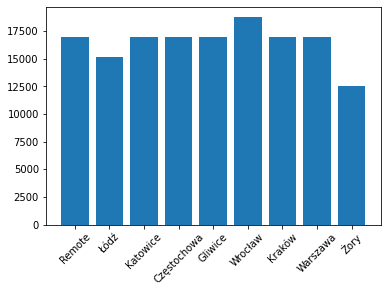

In [16]:
plt.bar(locations,avg_salary)
plt.xticks(rotation = 45)
plt.show()